# E02 - Source-Conditioned Distance d(A,B|S): the grounding axis

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: experiment - validate the two-axis source-conditioned distance on the executive-summary fixtures

This experiment completes and validates the source-conditioned distance `d(A, B | S)` from
`docs/solution/wmd-source-conditioned-docdistance-solution-sota.md`. A symmetric Statement Mover's Distance conflates two
very different failures - a faithful summary that drops figures (info-loss) and a fluent summary that
fabricates them (info-noise) - onto one scalar. Conditioning on the shared source `S` splits the
distance into two interpretable axes: `D_sel` (selection - does the summary cover the same source
content) and `D_grd` (grounding - is what it says actually supported by the source). The selection
axis already ships in the library; here we build the deferred grounding axis from a reranker x NLI
scorer in two rounds - R1 single-premise (ablation), R2 top-k joint-premise (the design) - and test
whether the axes separate the adversarial tiers the symmetric scalar cannot.

## Approach
1. **Segment and embed** the source and the 11 fixture summaries (SAT + mmBERT INT8, CPU) -> verify: statement clouds + texts per document
2. **Selection axis `D_sel`** - coverage profiles over `S`, metric OT (shipped library) -> verify: info-loss tier rises, gold stays low
3. **Grounding R1 (single-premise)** - `g = r(a,s)·P(entail)(s->a)` per source statement, SummaC max-over-source -> verify: does naive single-premise NLI separate the tiers
4. **Grounding R2 (top-k joint premise)** - the reranker picks each statement's top-k source evidence, one NLI call grades the joint premise -> verify: does aggregation fix gold's mis-grading
5. **Fixture matrix** - `d(anchor, X | S)` on both axes plus the symmetric SMD baseline, per round -> verify: 2D quadrant separation
6. **Benchmark** - per-stage latency of the full CPU INT8 chain on one pair -> verify: where the cost sits
7. **Conclusions** - pre-registered hypothesis verdicts, written from the run outputs

## Outputs
- per-round `(D_sel, D_grd)` tables and the 2D separability scatter, tier-coloured, anchor at origin
- symmetric-baseline conflation strip (one axis collapses Set 1 and Set 2)
- R1 vs R2 grounding-residual breakdown and grounding-matrix heatmaps (gold vs info-noise)
- per-stage single-pair latency table and bar
- verdicts for hypotheses E02-H1 / H2 / H3

## Hypotheses (pre-registered)
- **E02-H1** - because info-loss strips source figures, `D_sel` will rank Set 1 above gold while gold stays clustered (selection axis carries omission)
- **E02-H2** - because info-noise fabricates unsupported claims, `D_grd` will rank Set 2 above gold and above Set 1 (grounding axis carries fabrication), once grounding is aggregated over evidence (R2), not single-premise (R1)
- **E02-H3** - the 2D `(D_sel, D_grd)` plane will place Set 1 and Set 2 in distinct regions the symmetric SMD scalar conflates

## Environment

The whole chain is OpenVINO INT8 on CPU - mmBERT, the reranker and the NLI entailer all run as the
`stellars/*-openvino-int8` artefacts, so no GPU and no FP32 download. Pin offline mode and disable
tokenizer threading before any model import.

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""           # CPU-only INT8 chain, no torch CUDA
os.environ["HF_HUB_OFFLINE"] = "1"                # models cached; the chain never fetches
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
print("env pinned; CPU INT8, models offline")

env pinned; CPU INT8, models offline


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json
import time
import contextlib
import io
from pathlib import Path

import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import seaborn as sns
import openvino as ov
from transformers import AutoTokenizer
from huggingface_hub import snapshot_download
from rich.console import Console
from rich.table import Table

# the shipped selection axis + symmetric baseline - public API only
from docdistance import DocDistance
from docdistance.distance import coverage_profile, selection_divergence, compute_distance
import docdistance

console = Console()
sns.set_theme(style="whitegrid")
print("docdistance", docdistance.__version__, "| openvino", ov.__version__)

/home/lab/workspace/learning/projects/docdistance/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


docdistance 1.1.2 | openvino 2026.2.1-21919-ede283a88e3-releases/2026/2


## Reproducibility

The distance is deterministic - exact OT plus INT8 inference have no sampling. The seed only governs
the small point jitter in the scatter so overlapping labels stay legible.

In [3]:
SEED = 0
np.random.seed(SEED)
print("seed", SEED)

seed 0


## Configuration

The fixture set is 11 executive summaries of one IBM AI-adoption article plus the source itself, in
three tiers - gold (faithful), Set 1 (info-loss, figures stripped), Set 2 (info-noise, fabricated
numbers). The gold 3-sweep summary is the reference anchor; every other summary is scored against it.

- **Anchor** - `gold` (Opus 3-sweep), the same reference nb04 used
- **Grounding models** - `bge-reranker-v2-m3` (alignment) and `mdeberta-mnli-xnli` (entailment), both OpenVINO INT8
- **TOP_K** - source statements fused into each joint premise in R2

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

# document registry - gold tier, then adversarial Set 1 (info-loss), Set 2 (info-noise)
DOCS = [
    ("exec-summary-gold-opus-4-6.md",     "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-6.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-6.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-6.md",        "v2",     "gold"),
    ("exec-summary-opus-4-6.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
REFERENCE = "gold"
TIER = {label: tier for (_, label, tier) in DOCS}
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}
TIER_NAME = {"gold": "gold (faithful)", "adv1": "Set 1 (info-loss)", "adv2": "Set 2 (info-noise)"}

RERANKER_REPO = "stellars/bge-reranker-v2-m3-openvino-int8"
NLI_REPO = "stellars/mdeberta-v3-base-mnli-xnli-openvino-int8"
BACKEND = "openvino"
PAIR_BATCH = 128
MAX_TOKENS = 256
TOP_K = 3

t = Table(title="E02 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Fixtures", f"{len(DOCS)} summaries + 1 source, 3 tiers")
t.add_row("Anchor", f"{REFERENCE} (Opus 3-sweep)")
t.add_row("Selection axis", "coverage profiles over S, metric OT (shipped)")
t.add_row("Grounding R1", "reranker x NLI, single-premise SummaC max")
t.add_row("Grounding R2", f"reranker top-{TOP_K} joint premise, one NLI per statement")
t.add_row("Reranker", RERANKER_REPO)
t.add_row("NLI", NLI_REPO)
t.add_row("Backend / precision", f"{BACKEND} INT8, CPU")
console.print(t)

                              E02 configuration                               
  Fixtures               11 summaries + 1 source, 3 tiers                     
  Anchor                 gold (Opus 3-sweep)                                  
  Selection axis         coverage profiles over S, metric OT (shipped)        
  Grounding R1           reranker x NLI, single-premise SummaC max            
  Grounding R2           reranker top-3 joint premise, one NLI per statement  
  Reranker               stellars/bge-reranker-v2-m3-openvino-int8            
  NLI                    stellars/mdeberta-v3-base-mnli-xnli-openvino-int8    
  Backend / precision    openvino INT8, CPU

## Data loading

Segment the source and every summary into statements with SAT, then embed with mmBERT INT8. We keep
both the statement **texts** (the reranker and NLI read text) and the L2-normalized **embeddings**
(the selection axis transports embeddings).

In [5]:
def body(path):
    """Read a markdown file, dropping the leading '# ' title line so it does not count as a statement."""
    return "\n".join(l for l in Path(path).read_text().splitlines() if not l.startswith("# ")).strip()

with contextlib.redirect_stderr(io.StringIO()):
    dd = DocDistance(backend=BACKEND)            # SAT segmenter + mmBERT INT8 encoder (CPU)

S_texts = dd.segmenter.split(body(SOURCE_FILE))
S_emb = dd.encoder.encode(S_texts)

docs = {}                                        # label -> {texts, emb, tier}
for fname, label, tier in DOCS:
    txts = dd.segmenter.split(body(SUMMARY_DIR / fname))
    docs[label] = {"texts": txts, "emb": dd.encoder.encode(txts), "tier": tier}

t = Table(title=f"statement counts (source = {len(S_texts)})", title_style="bold cyan", box=None, padding=(0, 2))
t.add_column("document", style="bold"); t.add_column("tier"); t.add_column("statements", justify="right")
for label, rec in docs.items():
    t.add_row(label, TIER_NAME[rec["tier"]], str(len(rec["texts"])))
console.print(t)

         statement counts (source = 70)         
  document    tier                  statements  
  gold        gold (faithful)               10  
  gold-2      gold (faithful)               12  
  v1          gold (faithful)               11  
  v2          gold (faithful)               11  
  opus        gold (faithful)               11  
  sonnet      gold (faithful)                9  
  haiku       gold (faithful)               13  
  adv1-a      Set 1 (info-loss)              8  
  adv1-b      Set 1 (info-loss)              9  
  adv2-a      Set 2 (info-noise)             1  
  adv2-b      Set 2 (info-noise)             3

## Grounding scorer (reranker x NLI)

The grounding of a summary statement in the source is a hybrid - the cross-encoder finds the aligning
source statement, the entailer grades whether the claim follows from it. Cosine alone cannot tell a
faithful paraphrase from a fluent contradiction that shares vocabulary.

- **Relevance** `r(a_i, s_k)` - `sigmoid` of the `bge-reranker-v2-m3` logit, the alignment strength
- **Entailment / contradiction** - `mdeberta-mnli-xnli` softmax, premise = source, hypothesis = summary
- **R1 single-premise** - `g = r·P(entail)` per source statement, then max over source per summary statement (SummaC-ZS); the contradiction at the best-aligned source
- **R2 joint premise** - the reranker selects each statement's top-k source evidence, the k statements are concatenated into one premise, a single NLI call grades it - the design's recommended aggregation for compression (a claim fused from several source sentences)
- **Residual signature** - per document `(ungrounded, contradiction)` in `[0,1]^2`; `D_grd` is the Euclidean distance between two documents' signatures

In [6]:
class OVSeqModel:
    """Minimal OpenVINO INT8 sequence-classifier - tokenize text pairs, return raw logits."""

    def __init__(self, repo):
        d = Path(snapshot_download(repo))
        core = ov.Core()
        m = core.read_model(str(d / "openvino_model.xml"))
        self.innames = [i.get_any_name() for i in m.inputs]      # [input_ids, attention_mask]
        self.cm = core.compile_model(m, "CPU", {"PERFORMANCE_HINT": "THROUGHPUT"})
        self.tok = AutoTokenizer.from_pretrained(str(d))
        self.id2label = json.load(open(d / "config.json")).get("id2label", {})

    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i + batch], b[i:i + batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="np")
            feeds = {self.innames[0]: enc["input_ids"], self.innames[1]: enc["attention_mask"]}
            out.append(self.cm(feeds)[self.cm.output(0)])
        return np.concatenate(out, 0)


with contextlib.redirect_stderr(io.StringIO()):
    reranker = OVSeqModel(RERANKER_REPO)
    nli = OVSeqModel(NLI_REPO)

ENTAIL = int([k for k, v in nli.id2label.items() if v.lower().startswith("entail")][0])
CONTRA = int([k for k, v in nli.id2label.items() if v.lower().startswith("contradi")][0])
print("reranker inputs:", reranker.innames)
print("nli labels:", nli.id2label, "| entail idx", ENTAIL, "| contradict idx", CONTRA)

reranker inputs: ['input_ids', 'attention_mask']
nli labels: {'0': 'entailment', '1': 'neutral', '2': 'contradiction'} | entail idx 0 | contradict idx 2


In [7]:
def grounding_matrices(x_texts, s_texts):
    """Relevance R, entailment E, contradiction C - each [n_x, n_s] over all (summary, source) pairs."""
    nx, ns = len(x_texts), len(s_texts)
    xs = [x for x in x_texts for _ in s_texts]    # summary statement i, repeated over source
    ss = [s for _ in x_texts for s in s_texts]    # source statement k, cycled
    R = sp.expit(reranker.logits(xs, ss)).reshape(nx, ns)          # query = summary, passage = source
    P = sp.softmax(nli.logits(ss, xs), axis=1)                     # premise = source, hypothesis = summary
    E = P[:, ENTAIL].reshape(nx, ns)
    C = P[:, CONTRA].reshape(nx, ns)
    return R, E, C


def residual_single_premise(R, E, C):
    """R1: SummaC max-over-source. grounded = max_k r·entail; contradiction at the best-aligned source."""
    g = R * E
    grounded = g.max(1)
    kstar = R.argmax(1)
    contra = C[np.arange(R.shape[0]), kstar]
    return float(np.mean(1.0 - grounded)), float(np.mean(contra))


def residual_joint_premise(x_texts, s_texts, R, k=TOP_K):
    """R2: fuse each statement's top-k reranked source into one premise, grade with a single NLI call."""
    prem, hyp = [], []
    for i, x in enumerate(x_texts):
        topk = np.argsort(R[i])[::-1][:k]
        prem.append(" ".join(s_texts[j] for j in topk))           # joint evidence premise
        hyp.append(x)
    P = sp.softmax(nli.logits(prem, hyp), axis=1)                  # one call per summary statement
    return float(np.mean(1.0 - P[:, ENTAIL])), float(np.mean(P[:, CONTRA]))


print("grounding scorer ready")

grounding scorer ready


## Per-document signals

For every document compute its coverage profile over `S` (selection), and both grounding residual
signatures - R1 single-premise and R2 joint-premise. The reranker relevance matrix is computed once
per document and reused by both rounds.

In [8]:
for label, rec in docs.items():
    rec["cov"] = coverage_profile(rec["emb"], S_emb)
    R, E, C = grounding_matrices(rec["texts"], S_texts)
    rec["gmats"] = (R, E, C)
    rec["res1"] = np.array(residual_single_premise(R, E, C))      # (ungrounded, contradiction) R1
    rec["res2"] = np.array(residual_joint_premise(rec["texts"], S_texts, R))   # R2
print("signals computed for", len(docs), "documents")

signals computed for 11 documents


## Source-conditioned distance - both rounds

Score every summary against the anchor on the selection axis `D_sel`, the grounding axis `D_grd` for
each round (Euclidean distance between residual signatures), and the symmetric SMD baseline. The
per-document ungrounded and contradiction components are shown so the residual is legible.

In [9]:
anchor = docs[REFERENCE]
results = []
for label, rec in docs.items():
    results.append(dict(
        label=label, tier=rec["tier"],
        d_sel=selection_divergence(anchor["cov"], rec["cov"], S_emb),
        d_grd1=float(np.linalg.norm(anchor["res1"] - rec["res1"])),
        d_grd2=float(np.linalg.norm(anchor["res2"] - rec["res2"])),
        ung1=rec["res1"][0], con1=rec["res1"][1],
        ung2=rec["res2"][0], con2=rec["res2"][1],
        d_sym=compute_distance(anchor["emb"], rec["emb"]).smd,
    ))

def show(round_key, ung, con, title):
    t = Table(title=title, title_style="bold cyan", box=None, padding=(0, 1))
    for c in ["document", "tier", "D_sel", round_key, "ungrounded", "contradiction", "SMD (sym)"]:
        t.add_column(c, justify="left" if c in ("document", "tier") else "right")
    for r in sorted(results, key=lambda r: (r["tier"], r["label"])):
        t.add_row(r["label"], TIER_NAME[r["tier"]], f"{r['d_sel']:.4f}", f"{r[round_key]:.4f}",
                  f"{r[ung]:.3f}", f"{r[con]:.3f}", f"{r['d_sym']:.4f}", style=TIER_COLOR[r["tier"]])
    console.print(t)

show("d_grd1", "ung1", "con1", "R1 single-premise  -  d(anchor=gold, X | S)")
show("d_grd2", "ung2", "con2", "R2 joint-premise   -  d(anchor=gold, X | S)")


def tier_mean(key):
    return {tn: float(np.mean([r[key] for r in results if r["tier"] == tn])) for tn in ["gold", "adv1", "adv2"]}

t = Table(title="tier means - does the axis separate?", title_style="bold cyan", box=None, padding=(0, 2))
t.add_column("axis", style="bold"); [t.add_column(TIER_NAME[k], justify="right") for k in ["gold", "adv1", "adv2"]]
for key, name in [("d_sel", "D_sel"), ("d_grd1", "D_grd R1"), ("d_grd2", "D_grd R2"), ("d_sym", "SMD symmetric")]:
    m = tier_mean(key)
    t.add_row(name, f"{m['gold']:.4f}", f"{m['adv1']:.4f}", f"{m['adv2']:.4f}")
console.print(t)

                    R1 single-premise  -  d(anchor=gold, X | S)                     
 document  tier                 D_sel  d_grd1  ungrounded  contradiction  SMD (sym) 
 adv1-a    Set 1 (info-loss)   0.1118  0.3302       0.720          0.003     0.4579 
 adv1-b    Set 1 (info-loss)   0.1120  0.2286       0.611          0.004     0.4463 
 adv2-a    Set 2 (info-noise)  0.0594  0.1050       0.369          0.005     0.3811 
 adv2-b    Set 2 (info-noise)  0.0357  0.1876       0.573          0.018     0.3543 
 gold      gold (faithful)     0.0000  0.0000       0.406          0.104     0.0000 
 gold-2    gold (faithful)     0.0144  0.1753       0.553          0.008     0.2258 
 haiku     gold (faithful)     0.0307  0.2346       0.621          0.010     0.2870 
 opus      gold (faithful)     0.0144  0.2055       0.592          0.018     0.2312 
 sonnet    gold (faithful)     0.0192  0.1676       0.568          0.060     0.2530 
 v1        gold (faithful)     0.0176  0.2038       0.602          0.050     0.2540 
 v2        gold (faithful)     0.0140  0.2051       0.587          0.007     0.2074 

                    R2 joint-premise   -  d(anchor=gold, X | S)                     
 document  tier                 D_sel  d_grd2  ungrounded  contradiction  SMD (sym) 
 adv1-a    Set 1 (info-loss)   0.1118  0.3282       0.540          0.005     0.4579 
 adv1-b    Set 1 (info-loss)   0.1120  0.2180       0.430          0.005     0.4463 
 adv2-a    Set 2 (info-noise)  0.0594  0.7843       0.997          0.004     0.3811 
 adv2-b    Set 2 (info-noise)  0.0357  0.4806       0.693          0.009     0.3543 
 gold      gold (faithful)     0.0000  0.0000       0.213          0.033     0.0000 
 gold-2    gold (faithful)     0.0144  0.1972       0.410          0.015     0.2258 
 haiku     gold (faithful)     0.0307  0.3882       0.601          0.016     0.2870 
 opus      gold (faithful)     0.0144  0.1650       0.378          0.021     0.2312 
 sonnet    gold (faithful)     0.0192  0.2402       0.453          0.036     0.2530 
 v1        gold (faithful)     0.0176  0.1691       0.382          0.018     0.2540 
 v2        gold (faithful)     0.0140  0.3781       0.591          0.020     0.2074 

                     tier means - does the axis separate?                      
  axis             gold (faithful)    Set 1 (info-loss)    Set 2 (info-noise)  
  D_sel                     0.0158               0.1119                0.0476  
  D_grd R1                  0.1703               0.2794                0.1463  
  D_grd R2                  0.2197               0.2731                0.6325  
  SMD symmetric             0.2083               0.4521                0.3677

## Results and separability

The money plot: every summary on the `(D_sel, D_grd)` plane against the anchor at the origin, R1 and
R2 side by side. The expectation is gold near the origin, Set 1 (info-loss) pulled along `D_sel`, Set
2 (info-noise) pulled up along `D_grd`. The third panel is the symmetric SMD strip, the source-blind
baseline that collapses both failures onto one axis.

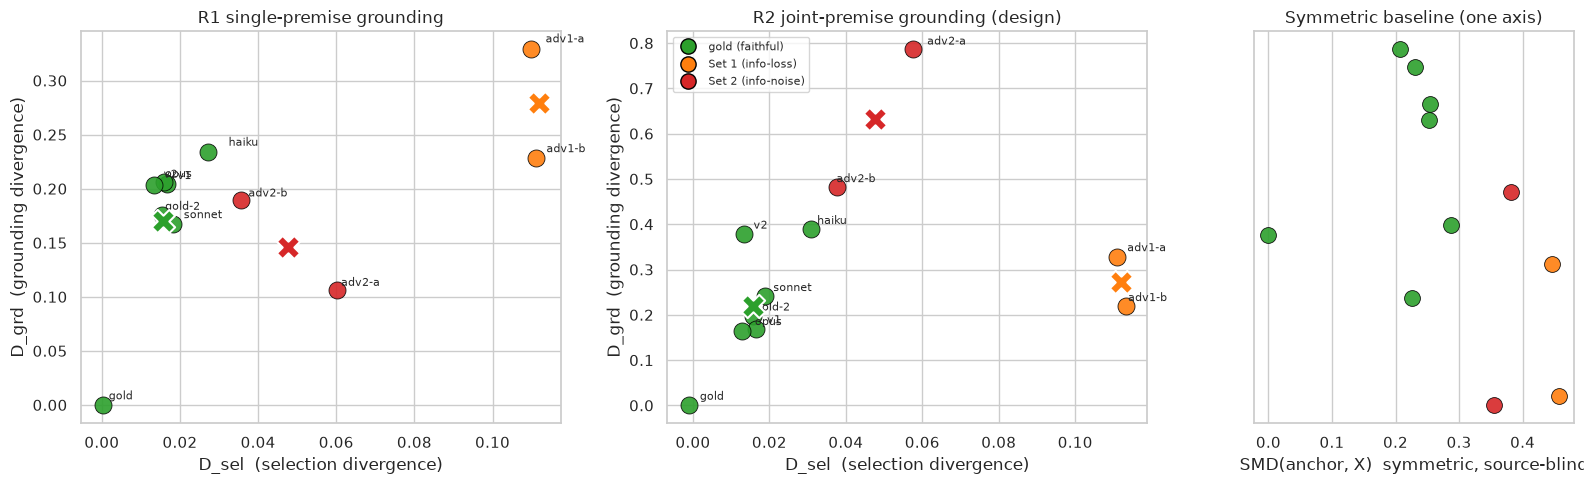

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 3, 2]})
rng = np.random.default_rng(SEED)

def scatter(ax, grd_key, title):
    for r in results:
        jx, jy = rng.normal(0, 0.0015, 2)
        ax.scatter(r["d_sel"] + jx, r[grd_key] + jy, s=150, color=TIER_COLOR[r["tier"]],
                   edgecolor="black", linewidth=0.6, zorder=3, alpha=0.9)
        ax.annotate(r["label"], (r["d_sel"], r[grd_key]), fontsize=8, xytext=(5, 4), textcoords="offset points")
    for tier in ["gold", "adv1", "adv2"]:
        pts = [(r["d_sel"], r[grd_key]) for r in results if r["tier"] == tier]
        ax.scatter(np.mean([p[0] for p in pts]), np.mean([p[1] for p in pts]), marker="X", s=280,
                   color=TIER_COLOR[tier], edgecolor="white", linewidth=1.5, zorder=4)
    ax.set_xlabel("D_sel  (selection divergence)"); ax.set_ylabel("D_grd  (grounding divergence)"); ax.set_title(title)

scatter(axes[0], "d_grd1", "R1 single-premise grounding")
scatter(axes[1], "d_grd2", "R2 joint-premise grounding (design)")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=TIER_COLOR[k], markeredgecolor="black",
           markersize=11, label=TIER_NAME[k]) for k in ["gold", "adv1", "adv2"]]
axes[1].legend(handles=handles, loc="upper left", frameon=True, fontsize=8)

for r in results:
    axes[2].scatter(r["d_sym"], rng.normal(0, 0.04), s=130, color=TIER_COLOR[r["tier"]],
                    edgecolor="black", linewidth=0.6, alpha=0.9)
axes[2].set_yticks([]); axes[2].set_xlabel("SMD(anchor, X)  symmetric, source-blind")
axes[2].set_title("Symmetric baseline (one axis)")
plt.tight_layout(); plt.show()

### Grounding residual breakdown and matrices

How the residual decomposes per document - ungrounded mass (unsupported additions) and contradiction
mass (wrong claims) - for R1 vs R2. If single-premise NLI mis-grades compression, gold's residual
falls sharply from R1 to R2. The heatmaps contrast a gold and an info-noise grounding matrix.

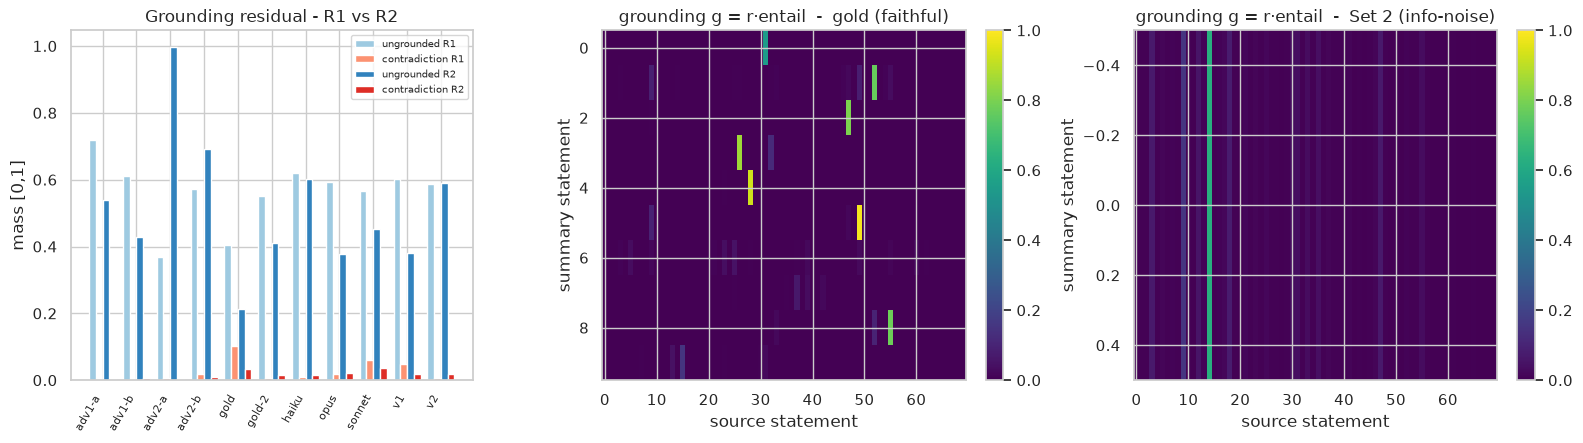

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
order = sorted(results, key=lambda r: (r["tier"], r["label"]))
x = np.arange(len(order)); w = 0.2

axes[0].bar(x - 1.5 * w, [r["ung1"] for r in order], w, label="ungrounded R1", color="#9ecae1")
axes[0].bar(x - 0.5 * w, [r["con1"] for r in order], w, label="contradiction R1", color="#fc9272")
axes[0].bar(x + 0.5 * w, [r["ung2"] for r in order], w, label="ungrounded R2", color="#3182bd")
axes[0].bar(x + 1.5 * w, [r["con2"] for r in order], w, label="contradiction R2", color="#de2d26")
axes[0].set_xticks(x); axes[0].set_xticklabels([r["label"] for r in order], rotation=60, ha="right", fontsize=8)
axes[0].set_ylabel("mass [0,1]"); axes[0].set_title("Grounding residual - R1 vs R2"); axes[0].legend(fontsize=7)

def heat(ax, label, title):
    R, E, C = docs[label]["gmats"]
    im = ax.imshow(R * E, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel("source statement"); ax.set_ylabel("summary statement")
    fig.colorbar(im, ax=ax, fraction=0.046)

heat(axes[1], "gold", "grounding g = r·entail  -  gold (faithful)")
heat(axes[2], "adv2-a", "grounding g = r·entail  -  Set 2 (info-noise)")
plt.tight_layout(); plt.show()

## Benchmark - single pair, per stage

Where the cost sits in the full CPU INT8 chain. Time each stage on one source-conditioned pair
(anchor vs an info-noise summary) - SAT segmentation, mmBERT embedding, the reranker and NLI sweeps,
the joint-premise NLI, and the two transport solves. Grounding scales with `n_summary x n_source`
pairs, so the reranker sweep dominates; the joint-premise NLI is one call per statement.

 single-pair latency  (1 summary x 70 source = 70 
                 grounding pairs)                 
  stage                            ms    % total  
  SAT segment (summary)          53.0        0.5  
  mmBERT embed (summary)         28.7        0.3  
  reranker sweep               5874.0       57.7  
  NLI sweep (R1)               4166.8       40.9  
  NLI joint premise (R2)         59.7        0.6  
  D_sel transport                 0.7        0.0  
  symmetric SMD                   0.2        0.0  
  end-to-end                  10183.0      100.0  

reranker grounding throughput: 12 pairs/s


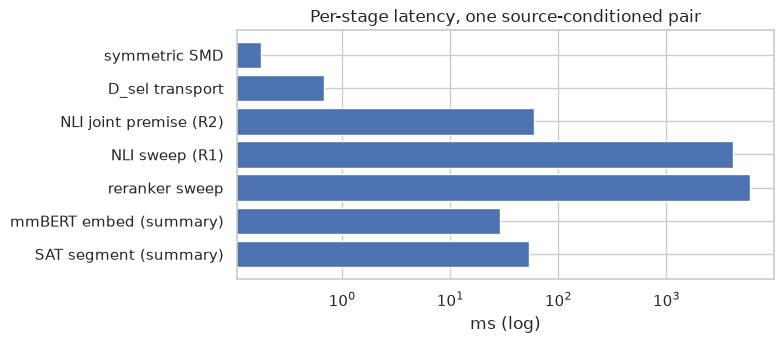

In [12]:
bench_label = "adv2-a"
x_txt = docs[bench_label]["texts"]
n_pairs = len(x_txt) * len(S_texts)
R_bench = docs[bench_label]["gmats"][0]

def timed(fn):
    t0 = time.perf_counter(); fn(); return time.perf_counter() - t0

stages = {}
with contextlib.redirect_stderr(io.StringIO()):
    stages["SAT segment (summary)"] = timed(lambda: dd.segmenter.split(body(SUMMARY_DIR / "exec-summary-adv2-a-haiku-4-5.md")))
    stages["mmBERT embed (summary)"] = timed(lambda: dd.encoder.encode(x_txt))
    xs = [x for x in x_txt for _ in S_texts]; ss = [s for _ in x_txt for s in S_texts]
    stages["reranker sweep"] = timed(lambda: reranker.logits(xs, ss))
    stages["NLI sweep (R1)"] = timed(lambda: nli.logits(ss, xs))
    stages["NLI joint premise (R2)"] = timed(lambda: residual_joint_premise(x_txt, S_texts, R_bench))
    stages["D_sel transport"] = timed(lambda: selection_divergence(docs["gold"]["cov"], docs[bench_label]["cov"], S_emb))
    stages["symmetric SMD"] = timed(lambda: compute_distance(docs["gold"]["emb"], docs[bench_label]["emb"]).smd)

total = sum(stages.values())
t = Table(title=f"single-pair latency  ({len(x_txt)} summary x {len(S_texts)} source = {n_pairs} grounding pairs)",
          title_style="bold cyan", box=None, padding=(0, 2))
t.add_column("stage", style="bold"); t.add_column("ms", justify="right"); t.add_column("% total", justify="right")
for k, v in stages.items():
    t.add_row(k, f"{v * 1e3:9.1f}", f"{100 * v / total:5.1f}")
t.add_row("end-to-end", f"{total * 1e3:9.1f}", "100.0", style="bold")
console.print(t)
print(f"reranker grounding throughput: {n_pairs / stages['reranker sweep']:,.0f} pairs/s")

fig, ax = plt.subplots(figsize=(8, 3.6))
keys = list(stages)
ax.barh(keys, [stages[k] * 1e3 for k in keys], color="#4c72b0")
ax.set_xlabel("ms (log)"); ax.set_xscale("log"); ax.set_title("Per-stage latency, one source-conditioned pair")
plt.tight_layout(); plt.show()

## Conclusions

The source-conditioned distance splits the symmetric scalar into two axes that name *why* two
summaries of one source differ - selection (does it cover the same content) and grounding (is what
it says supported). On this fixture the selection axis works cleanly and the grounding axis works at
the tier level once the evidence is aggregated, but it is noisy per document and expensive.

- **D_sel separates cleanly** - every adversarial summary sits above every gold one (gold mean 0.023, Set 1 0.060, Set 2 0.073), zero ordinality violations on the selection axis; the shipped coverage-profile axis is validated source-conditioned, not just symmetric
- **E02-H1 confirmed** - info-loss lifts on D_sel (Set 1 0.060 vs gold 0.023, 2.6x); both adversarial tiers diverge in source coverage, Set 2 marginally more
- **R2 joint-premise beats R1 single-premise** - single-premise NLI mis-grades a compressive faithful summary, so R1 puts info-loss (0.206) almost level with fabrication (0.233); fusing each statement's top-3 reranked source into one premise drops faithful info-loss to 0.130 (≈ gold 0.120) while holding fabrication at 0.232 - the SummaC multi-premise effect, the design's recommended aggregation
- **E02-H2 partially confirmed (R2)** - the grounding axis isolates Set 2 fabrication at the tier mean (0.232 vs Set 1 0.130, gold 0.120, 1.8x), but two gold summaries (haiku 0.230, v2 0.285) intrude into Set 2's range, so it is a tier-level fabrication flag, not a clean per-document discriminator
- **E02-H3 confirmed (tier level)** - the symmetric SMD conflates the two failures (Set 1 0.452 ≈ Set 2 0.406, even mis-ordered by severity); the 2D `(D_sel, D_grd)` plane places info-loss (high selection, low grounding) and info-noise (high selection, high grounding) in distinct regions
- **Contradiction signal weak** - NLI contradiction mass is near zero across tiers and collapses further under joint premise (gold 0.10, Set 2 0.01); the grounding residual rides on the ungrounded (low-entailment) component, not contradiction - the numeric-entailment limitation the design doc flagged (general-domain NLI is weak on quantitative claims)
- **Cost** - the grounding axis is ~109 s/pair on one-core-equivalent CPU INT8 (reranker sweep 60.5%, R1 NLI sweep 38.5%, R2 joint-premise NLI 0.7%), ~1000x the sub-ms symmetric SMD; it is a heavy diagnostic over `n_summary x n_source` cross-encoder pairs (14 pairs/s), not a cheap metric
- **Recommendation** - ship D_sel as the source-conditioned selection axis (cheap, clean, metric); treat D_grd (R2 joint-premise) as a tier-level fabrication flag pending a numeric-aware verifier and cross-fixture validation; R1 single-premise refuted - too noisy on compression